In [1]:
import pandas as pd
import numpy as np

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

import joblib
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
X = pd.read_csv("../dataset/X_train_1k.csv")

scaler = joblib.load("../models/scaler.pkl")

X_scaled = scaler.transform(X)

print(X_scaled.shape)

(1000, 4)


In [3]:
kmeans = joblib.load("../models/kmeans_model.pkl")

dbscan = joblib.load("../models/dbscan_model.pkl")

In [4]:
kmeans_labels = kmeans.predict(X_scaled)

kmeans_silhouette = silhouette_score(
    X_scaled,
    kmeans_labels
)

kmeans_db = davies_bouldin_score(
    X_scaled,
    kmeans_labels
)

kmeans_ch = calinski_harabasz_score(
    X_scaled,
    kmeans_labels
)

print("KMeans Results")
print("Silhouette Score:", kmeans_silhouette)
print("Davies-Bouldin Score:", kmeans_db)
print("Calinski-Harabasz Score:", kmeans_ch)

KMeans Results
Silhouette Score: 0.6498834146418524
Davies-Bouldin Score: 0.7103703150447092
Calinski-Harabasz Score: 548.883086393226


In [5]:
from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(
    n_clusters=4,
    linkage="ward"
)

hierarchical_labels = hierarchical.fit_predict(
    X_scaled
)

hierarchical_silhouette = silhouette_score(
    X_scaled,
    hierarchical_labels
)

hierarchical_db = davies_bouldin_score(
    X_scaled,
    hierarchical_labels
)

hierarchical_ch = calinski_harabasz_score(
    X_scaled,
    hierarchical_labels
)

print("Hierarchical Results")
print("Silhouette Score:", hierarchical_silhouette)
print("Davies-Bouldin Score:", hierarchical_db)
print("Calinski-Harabasz Score:", hierarchical_ch)

Hierarchical Results
Silhouette Score: 0.6932627773706869
Davies-Bouldin Score: 0.6887499635860144
Calinski-Harabasz Score: 453.0393313339733


In [6]:
dbscan_labels = dbscan.fit_predict(
    X_scaled
)

mask = dbscan_labels != -1

if len(set(dbscan_labels[mask])) > 1:

    dbscan_silhouette = silhouette_score(
        X_scaled[mask],
        dbscan_labels[mask]
    )

    dbscan_db = davies_bouldin_score(
        X_scaled[mask],
        dbscan_labels[mask]
    )

    dbscan_ch = calinski_harabasz_score(
        X_scaled[mask],
        dbscan_labels[mask]
    )

else:

    dbscan_silhouette = np.nan
    dbscan_db = np.nan
    dbscan_ch = np.nan

print("DBSCAN Results")
print("Silhouette Score:", dbscan_silhouette)
print("Davies-Bouldin Score:", dbscan_db)
print("Calinski-Harabasz Score:", dbscan_ch)

DBSCAN Results
Silhouette Score: 0.7669815818655515
Davies-Bouldin Score: 0.3308900416060099
Calinski-Harabasz Score: 1064.540383342923


In [7]:
results = pd.DataFrame({
    "Model": [
        "KMeans",
        "Hierarchical",
        "DBSCAN"
    ],
    "Silhouette Score": [
        kmeans_silhouette,
        hierarchical_silhouette,
        dbscan_silhouette
    ],
    "Davies-Bouldin Score": [
        kmeans_db,
        hierarchical_db,
        dbscan_db
    ],
    "Calinski-Harabasz Score": [
        kmeans_ch,
        hierarchical_ch,
        dbscan_ch
    ]
})

results

,Model,Silhouette Score,Davies-Bouldin Score,Calinski-Harabasz Score
0,KMeans,0.649883,0.71037,548.883086
1,Hierarchical,0.693263,0.68875,453.039331
2,DBSCAN,0.766982,0.33089,1064.540383


In [8]:
best_model = results.loc[
    results["Silhouette Score"].idxmax(),
    "Model"
]

print("Best Model:", best_model)

Best Model: DBSCAN


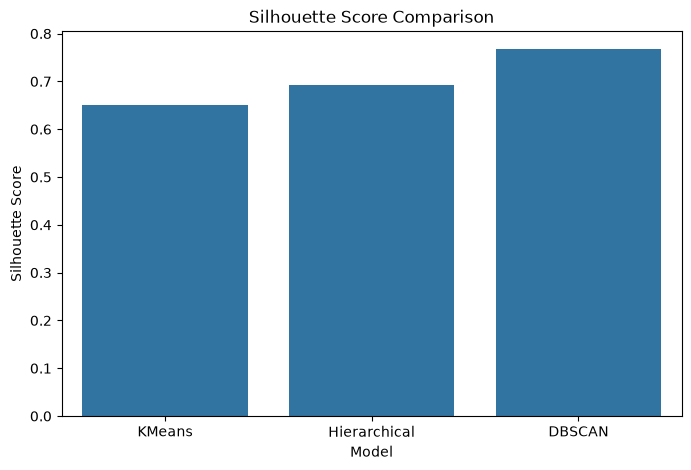

In [9]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="Silhouette Score"
)

plt.title("Silhouette Score Comparison")
plt.show()

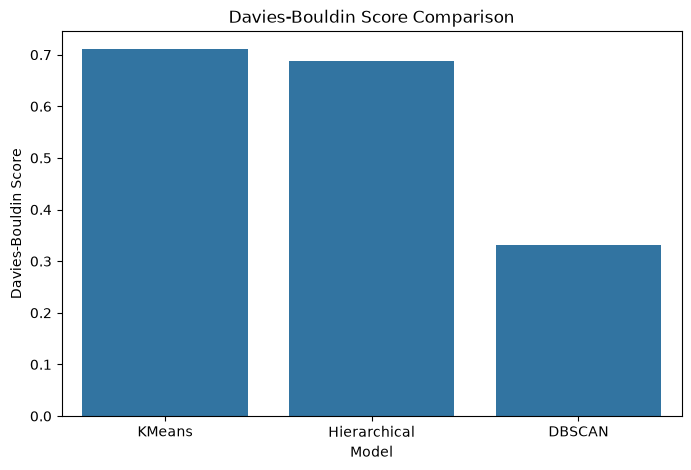

In [10]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="Davies-Bouldin Score"
)

plt.title("Davies-Bouldin Score Comparison")
plt.show()

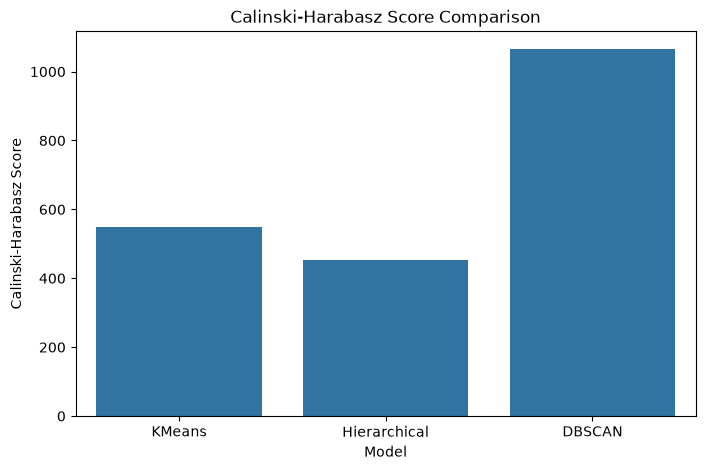

In [11]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="Calinski-Harabasz Score"
)

plt.title("Calinski-Harabasz Score Comparison")
plt.show()

In [12]:
print(
    f"The best clustering algorithm based on Silhouette Score is: {best_model}"
)

The best clustering algorithm based on Silhouette Score is: DBSCAN
